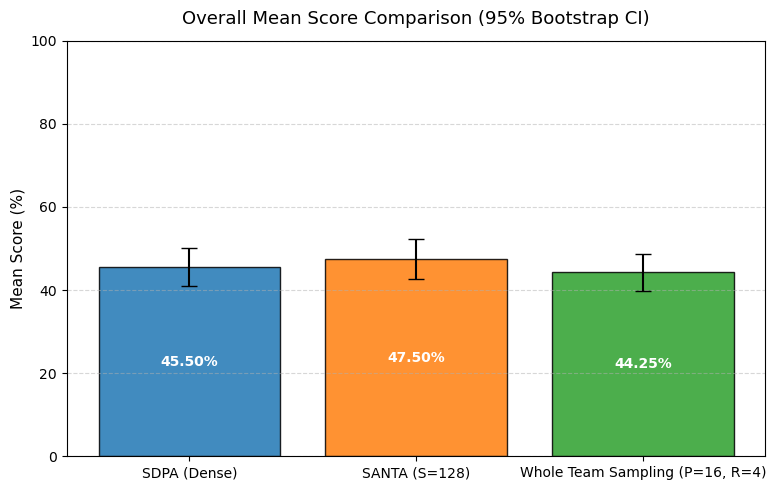

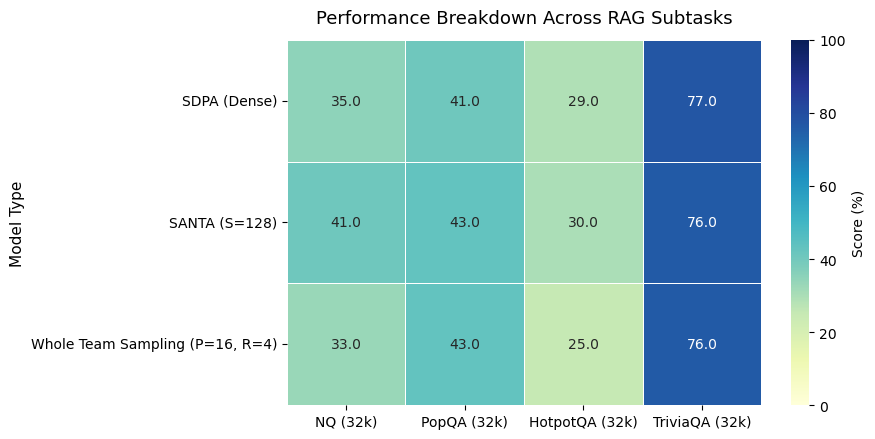

In [5]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def generate_rag_benchmark_plots(
    file_path="../benchmarks/helmet-rag-32k/S128-100/summary.json",
):
  # Load benchmark summary JSON
  if os.path.exists(file_path):
    with open(file_path, "r") as f:
      data = json.load(f)
  else:
    # Fallback to direct memory representation if file path is unavailable
    data = {
        "backends": {
            "sdpa": {
                "selected_task_unweighted_mean_score": 53.5,
                "score_confidence_interval": {"lower": 48.75, "upper": 58.25},
                "tasks": {
                    "kilt_nq_32k": {"score": 42.0},
                    "kilt_popqa_32k": {"score": 53.0},
                    "kilt_hotpotqa_32k": {"score": 37.0},
                    "kilt_triviaqa_32k": {"score": 82.0},
                },
            },
            "santa": {
                "selected_task_unweighted_mean_score": 53.75,
                "score_confidence_interval": {"lower": 49.25, "upper": 58.25},
                "tasks": {
                    "kilt_nq_32k": {"score": 42.0},
                    "kilt_popqa_32k": {"score": 52.0},
                    "kilt_hotpotqa_32k": {"score": 37.0},
                    "kilt_triviaqa_32k": {"score": 84.0},
                },
            },
            "team_gumbel_topk": {
                "selected_task_unweighted_mean_score": 53.0,
                "score_confidence_interval": {"lower": 48.5, "upper": 57.5},
                "tasks": {
                    "kilt_nq_32k": {"score": 38.0},
                    "kilt_popqa_32k": {"score": 54.0},
                    "kilt_hotpotqa_32k": {"score": 33.0},
                    "kilt_triviaqa_32k": {"score": 87.0},
                },
            },
        }
    }

  # Standardized model label mapping
  model_mapping = {
      "sdpa": "SDPA (Dense)",
      "santa": "SANTA (S=128)",
      "team_gumbel_topk": "Whole Team Sampling (P=16, R=4)",
  }

  backends = data["backends"]
  model_keys = [k for k in model_mapping.keys() if k in backends]
  model_names = [model_mapping[k] for k in model_keys]

  # ---------------------------------------------------------
  # 1. Bar Graph: Mean Scores with 95% Bootstrap Error Bars
  # ---------------------------------------------------------
  means = [
      backends[k]["selected_task_unweighted_mean_score"] for k in model_keys
  ]

  # Calculate asymmetric lower and upper error bounds
  ci_lower = [
      backends[k]["selected_task_unweighted_mean_score"]
      - backends[k]["score_confidence_interval"]["lower"]
      for k in model_keys
  ]
  ci_upper = [
      backends[k]["score_confidence_interval"]["upper"]
      - backends[k]["selected_task_unweighted_mean_score"]
      for k in model_keys
  ]
  yerr = [ci_lower, ci_upper]

  fig, ax = plt.subplots(figsize=(8, 5))
  colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
  bars = ax.bar(
      model_names,
      means,
      yerr=yerr,
      capsize=6,
      color=colors[: len(model_keys)],
      alpha=0.85,
      edgecolor="black",
  )

  ax.set_ylabel("Mean Score (%)", fontsize=11)
  ax.set_title(
      "Overall Mean Score Comparison (95% Bootstrap CI)",
      fontsize=13,
      pad=12,
  )
  ax.set_ylim(0, 100)
  ax.grid(axis="y", linestyle="--", alpha=0.5)

  for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2.0,
        f"{height:.2f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

  plt.tight_layout()
  plt.savefig("overall_score_comparison.png", dpi=300)
  plt.show()

  # ---------------------------------------------------------
  # 2. Heatmap: Task-Specific Performance Breakdown
  # ---------------------------------------------------------
  tasks = ["kilt_nq_32k", "kilt_popqa_32k", "kilt_hotpotqa_32k", "kilt_triviaqa_32k"]
  task_labels = [
      "NQ (32k)",
      "PopQA (32k)",
      "HotpotQA (32k)",
      "TriviaQA (32k)",
  ]

  matrix = []
  for k in model_keys:
    task_scores = [backends[k]["tasks"][t]["score"] for t in tasks]
    matrix.append(task_scores)

  df_heatmap = pd.DataFrame(matrix, index=model_names, columns=task_labels)

  fig, ax = plt.subplots(figsize=(9, 4.5))
  sns.heatmap(
      df_heatmap,
      annot=True,
      fmt=".1f",
      cmap="YlGnBu",
      cbar_kws={"label": "Score (%)"},
      vmin=0,
      vmax=100,
      linewidths=0.5,
      ax=ax,
  )

  ax.set_title("Performance Breakdown Across RAG Subtasks", fontsize=13, pad=12)
  ax.set_ylabel("Model Type", fontsize=11)
  plt.tight_layout()
  plt.savefig("task_performance_heatmap.png", dpi=300)
  plt.show()


if __name__ == "__main__":
  generate_rag_benchmark_plots()